<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Kundesucces-analyse</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Grundårsagsanalyse af kundeafgang</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">PROC FISHBONE årsag-virkning-diagram til en fastholdelsesgennemgang for mid-market B2B SaaS</div>
</div>

## Resumé

Denne analyse organiserer grundårsagerne til den forhøjede SaaS-kundeafgang i et struktureret årsag-virkning- (Ishikawa-) diagram. Mid-market B2B-segmentet har en afgang på ca. 18% årligt mod et mål på 8%. Tyve grundårsagsfund — hentet fra exit-undersøgelser, interviews med customer success og kohorteattribution — er grupperet i seks årsagskategorier og gengivet med `PROC FISHBONE` som et diagram med 27 knuder (én virkning, seks kategoriben, tyve delårsager).

Den understøttende `PROC MEANS`-opdeling viser, hvor den tilskrivelige afgang koncentrerer sig. **Produkt** har flest fund (5 årsager, i alt 48,1 effektpoint), efterfulgt af **Prissætning** (4 årsager, 42,3) og **Support** (4 årsager, 40,2). Målt på gennemsnitlig effekt *pr. årsag* er **Konkurrence** den mest alvorlige kategori (gennemsnit 11,8), og det enkeltfund med højest effekt samlet set er **Prissætning**s prisstigning ved fornyelse uden forudgående varsel (14,2). `PROC SGPLOT`-Pareto-visningen rangerer hver enkelt årsag, så ledelsen kan se, hvilke ben der skal handles på først. Leverancen indgår i Customer Success' kvartalsvise fastholdelsesgennemgang.

## Datakilder

| Kilde | Beskrivelse | Rækker |
|--------|-------------|--------|
| WORK.CHURN_RCA | Grundårsagsfund for kundeafgang samlet fra exit-undersøgelsesanalyse og CS-teamets retrospektiv; hver række er én årsag med sin kategori, understøttende evidens og estimeret andel af afgangseffekten | 20 |

---

In [1]:
/* --------------------------------------------------------
   Grundårsagsfund for kundeafgang (RCA)
   SaaS-platform, B2B mid-market-segment.
   Hver række: årsagskategori, den specifikke årsag, en
   understøttende delårsags-/evidensnote samt den estimerede
   andel af afgangen, der kan tilskrives den (fra exit-
   undersøgelser og kohorteattribution).
   -------------------------------------------------------- */
data work.churn_rca;
    INFILE DATALINES dlm='|' dsd truncover;
    INDDATA category :$15. cause :$70. subcause :$90. churn_impact_pct;
    DATALINES;
Produkt|Grundlæggende funktionshuller ift. virksomhedskonkurrenter|Masseeksport og API-hastighedsgrænser nævnt i 34% af exit-undersøgelser|12.4
Produkt|Begrænsede rapporteringsmuligheder|Ingen tilpasset dashboard-builder i standardniveauet|9.8
Produkt|Mobilappen halter efter webfunktionaliteten|3 centrale arbejdsgange kan ikke gennemføres af rene mobilbrugere|8.2
Produkt|Hyppige UI-ændringer uden varsel|Superbrugere forstyrres af kvartalsvise redesigns|7.6
Produkt|Huller i integrationsmarkedspladsen|Manglende native forbindelser til Salesforce og HubSpot|10.1
Prissætning|Prisstigning ved fornyelse uden forudgående varsel|18% stigning i MRR med 30 dages varsel|14.2
Prissætning|Pr.-bruger-model straffer teamvækst|Omkostningen fordobles, når teamet vokser fra 10 til 20|11.3
Prissætning|Den indledende rabat kan ikke fornyes|Prischok ved første fornyelse|9.7
Prissætning|Intet incitament til flerårig kontrakt|Årlig pris identisk med måned-til-måned|7.1
Support|Første svartid overstiger 24 timer|Niveaubenchmark er 4 timer|10.8
Support|Kvalitetshul i weekendsupport|Offshore-dækning mangler produktkendskab|9.3
Support|Ingen dedikeret CSM under Enterprise-niveauet|Mid-market-kunder har ingen navngiven kontakt|11.5
Support|Eskaleringsvejen er uklar for kunderne|38% af de tabte kunder nævnte forvirring om eskalering|8.6
Onboarding|Tid til værdiskabelse overstiger 90 dage|Implementeringskompleksitet blev ikke oplyst før salg|12.9
Onboarding|Selvbetjeningsdokumentation er forældet|Sidst opdateret for 11 måneder siden|8.1
Onboarding|Ingen guidede ture i appen for nye funktioner|Funktionsadoption under 30% efter 6 måneder|9.4
Konkurrence|Konkurrent til 30% lavere pris|Tre store kunder nævnte en specifik konkurrent|13.1
Konkurrence|Konkurrent tilbyder ubegrænset antal brugere|Fjerner straffen pr. bruger for voksende teams|10.6
Relation|Udskiftning af topledelsessponsor blev ikke håndteret|Fortaleren stoppede; intet genengagementsprogram|11.7
Relation|QBR-frekvens reduceret til årlig|Reduktion af CS-teamets ressourcer for 18 måneder siden|9.2
;
KØR;


NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: koncentration af afgangseffekt efter RCA-kategori.
   Sum viser, hvor den tilskrivelige afgang klumper sig; max
   markerer den enkelte værste årsag i hver kategori.
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.churn_rca n sum mean MAX maxdec=1;
    KLASSE category;
    VARIABEL churn_impact_pct;
    MÆRKAT category='Kategori' churn_impact_pct='Afgangseffekt (%)';
    TITEL 'Kundeafgang RCA: Effekt i procent efter kategori';
KØR;

                                    Kundeafgang RCA: Effekt i procent efter kategori                                    

                                                  The MEANS Procedure

                                 Analysis Variable : churn_impact_pct Afgangseffekt (%)

        Kategori              N Obs            Sum           Mean        Maximum
        ------------------------------------------------------------------------
        Konkurrence               2           23.7           11.8           13.1
        Onboarding                3           30.4           10.1           12.9
        Prissætning               4           42.3           10.6           14.2
        Produkt                   5           48.1            9.6           12.4
        Relation                  2           20.9           10.4           11.7
        Support                   4           40.2           10.1           11.5
        --------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                    Kundeafgang RCA: Effekt i procent efter kategori                                    




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


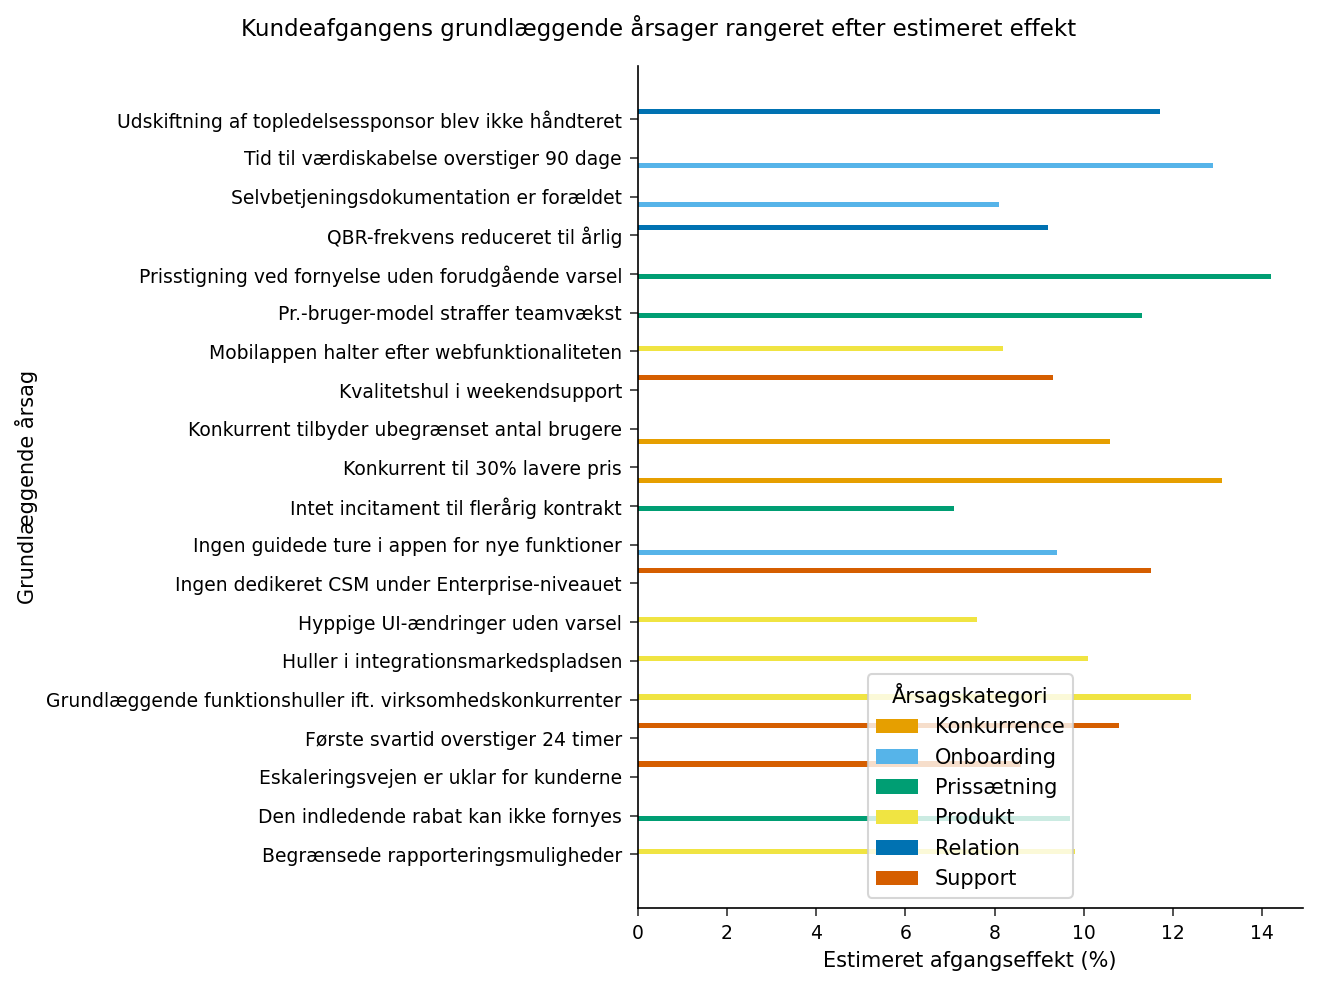

In [3]:
/* --------------------------------------------------------
   Pareto-visning: individuelle grundårsager rangeret efter
   estimeret afgangseffekt, farvet efter kategori. Dette
   supplerer fiskebensdiagrammet ved at kvantificere, hvilke
   "ben" der betyder mest.
   -------------------------------------------------------- */
PROCEDURE SORTER data=work.churn_rca;
    EFTER FALDENDE churn_impact_pct;
KØR;

PROCEDURE SGPLOT data=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS label='Estimeret afgangseffekt (%)';
    YAXIS label='Grundlæggende årsag' discreteorder=data;
    keylegend / title='Årsagskategori' position=bottom;
    TITEL 'Kundeafgangens grundlæggende årsager rangeret efter estimeret effekt';
KØR;

### Årsag-virkning- (Ishikawa-) diagram

`PROC FISHBONE` opbygger diagrammet direkte fra `WORK.CHURN_RCA`: hver distinkt `category` bliver et hovedben ud fra den centrale rygrad, og de enkelte `cause`-fund hænger fra deres kategoriben som delårsager. Proceduren udskriver den fulde årsag-virkning-struktur nedenfor — virkningen ved hovedet, de seks kategoriben og hver delårsag grupperet under sit ben — og skriver den tilhørende fiskebensgrafik til disk. Det rangerede Pareto-diagram ovenfor er den ledsagende visning, der kvantificerer, hvilke af disse ben der bærer den største tilskrivelige afgang.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: fiskebensdiagram for kundeafgangens
   årsag-og-virkning. Diagrammet er drevet direkte af
   WORK.CHURN_RCA, så de seks årsagskategorier og deres
   årsager er præcis de fund, der er analyseret ovenfor.
   CATEGORY danner hovedbenene; CAUSE hænger som delårsager
   fra hvert ben.
   -------------------------------------------------------- */
PROCEDURE fishbone data=work.churn_rca;
    cause category / subcause=cause;
    effect 'Forhøjet kundeafgang (18% årligt mod 8% mål)';
    TITEL 'Grundårsagsanalyse af kundeafgang - mid-market-segmentet';
    footnote 'Kilder: exit-undersøgelser, interviews med CS-teamet, kohorteattribution';
KØR;

                                    Kundeafgang RCA: Effekt i procent efter kategori                                    


                    Grundårsagsanalyse af kundeafgang - mid-market-segmentet
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Forhøjet kundeafgang (18% årligt mod 8% mål)
    [CAUSE] Prissætning (top)
      [SUB] Prisstigning ved fornyelse uden forudgående varsel
      [SUB] Pr.-bruger-model straffer teamvækst
      [SUB] Den indledende rabat kan ikke fornyes
      [SUB] Intet incitament til flerårig kontrakt
    [CAUSE] Konkurrence (top)
      [SUB] Konkurrent til 30% lavere pris
      [SUB] Konkurrent tilbyder ubegrænset antal brugere
    [CAUSE] Onboarding (top)
      [SUB] Tid til værdiskabelse overstiger 90 dage
      [SUB] Ingen guidede ture i appen for nye funktioner
      [SUB] Selvbetjeningsdokumentation er forældet
    [CAUSE] Produkt (bottom)
      [SUB] Grundlæggende funktionshuller ift. virksomhedskonkurrenter
      [S


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Fortolkning

Årsag-virkning-strukturen og `PROC MEANS`-tallene pr. kategori peger ledelsen mod et lille antal tiltag med stor gennemslagskraft. De to enkeltfund med højest effekt — **Prissætning**s prisstigning ved fornyelse uden varsel (14,2) og **Konkurrence**-fundet om, at en konkurrent sælger tilsvarende funktionalitet til 30% lavere pris (13,1) — er begge kommercielle snarere end produktmæssige problemer, hvilket antyder, at prisgennemsigtighed og konkurrencemæssig positionering er de mest presserende kortsigtede håndtag. **Onboarding**s tid til værdiskabelse på over 90 dage (12,9) er det største servicesidefund og hænger direkte sammen med forventningsafstemning før salg.

Målt på volumen dominerer **Produkt** diagrammet (5 ud af 20 fund, i alt 48,1 effektpoint), men dets fund er individuelt mindre (gennemsnit 9,6) end dem i **Konkurrence** (gennemsnit 11,8) eller **Prissætning** (gennemsnit 10,6) — en påmindelse om, at en lang liste af produkthuller ikke automatisk er den øverste prioritet. **Relation**-benet (udskiftning af topledelsessponsor og reduceret QBR-frekvens, i alt 20,9) repræsenterer procesændringer, som CS-teamet kan gennemføre inden for indeværende kvartal uden investering i produkt eller pris, og udgør den hurtigste vej til målbar forbedring af fastholdelsen. Den fulde rangerede liste i Pareto-diagrammet lader ledelsesteamet prioritere indsatser efter estimeret effekt frem for efter kategoristørrelse.

---

In [5]:
/* --------------------------------------------------------
   Eksportér RCA-fund om kundeafgang til
   strategigennemgangs-deck
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>